예제 실행 및 시각화를 위해 공통 라이브러리를 불러온다.
(공통 라이브러리에 대한 설명은 `code_reference/README.md` 파일을 참조)


In [1]:

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz
# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib에서 한글 폰트 사용 설정
common.set_korean_plot_env()



다음 셀은 결과 재현성을 보장하기 위해서 시드를 고정한다. 여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.


In [2]:

import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 4-3 공개 이미지 데이터셋의 사용

본 노트북은 본문 4-3 절의 코드 예제([코드 4-18] ~ [코드 4-24])를 절 흐름 그대로 모은 것이다. torchvision 내장 MNIST 데이터셋으로 다층 퍼셉트론 숫자 분류기를 만든다.

다루는 내용
- `datasets.MNIST` 내장 데이터셋 로드
- `Resize` / `ToTensor` / `Normalize` 이미지 변환과 `transforms.Compose`
- 50,000 / 10,000 훈련·검증 분리, 배치 크기 100 데이터로더
- 다층 퍼셉트론 숫자 분류기 모델 정의·학습·평가

> MNIST 자동 다운로드 데이터는 공개 저장소 규약(§13.9)에 따라 `root='../../download'` 로 받는다. 본문 경로는 `'../data'` 이며, 이 차이는 `_book` 에 기록한다.

이번 절은 본문의 모델 5의 구현을 포함한다. 모델 5의 제시문은 다음과 같다.

> **모델 5. MNIST 숫자 분류기**
>
> 다층 퍼셉트론 모델로 MNIST 데이터셋을 학습해 숫자 분류기 모델을 만든다. MNIST 데이터셋의 샘플은 0부터 9까지의 숫자 중 하나를 쓴 손 글씨 이미지로, 크기가 28x28인 회색조 이미지이다. 다음은 MNIST 데이터셋에서 숫자별로 샘플을 하나씩 고른 것이다. 
>
> (그림은 아래 [그림 4-2] 셀 참조)
>
> MNIST 데이터셋의 샘플 이미지를 1차원 텐서로 변환하는 데이터셋을 만들고, 이 데이터셋을 모델 학습과 예측에 사용한다.

## [코드 4-18] 파이토치 내장 MNIST 데이터셋으로 `Dataset` 객체 생성

`datasets.MNIST` 로 내장 데이터셋을 불러온다. `transform=None` 이면 원본은 Pillow 객체와 정답 정수의 튜플이다.

In [3]:
########################################################################################
# 코드 4-16 - 파이토치 내장 MNIST 데이터셋으로 Dataset 객체 생성
########################################################################################
from torchvision import datasets

# data_root: 내려받은 데이터셋을 저장할 디렉터리 경로
data_root = '../../download'

train_set = datasets.MNIST(root=data_root, train=True, download=True, transform=None)
test_set = datasets.MNIST(root=data_root, train=False, download=True, transform=None)

# 훈련 데이터셋의 첫 번째 샘플
print(train_set[0])              # PIL.Image.Image 객체(Pillow 객체)와 정답의 튜플

(<PIL.Image.Image image mode=L size=28x28 at 0x789512E23B10>, 5)


## 참고 - [그림 4-2] 대응: MNIST 샘플 이미지 격자

본문 [그림 4-2] 와 같이 0부터 9까지 숫자별 샘플 이미지를 하나씩 격자로 표시한다.

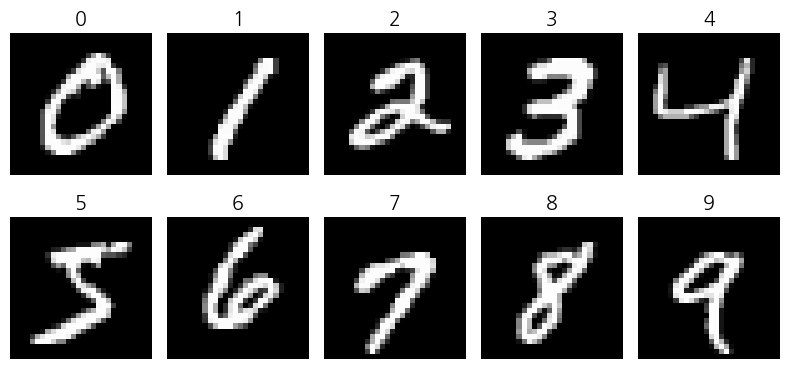

In [4]:
# 참고 - MNIST 샘플 이미지([그림 4-2])

targets = train_set.targets                      # 전체 정답 텐서 (60000,)
imgs, descs = [], []
for digit in range(10):
    idx = int((targets == digit).nonzero()[0])   # 각 숫자가 처음 등장하는 위치
    imgs.append(train_set[idx][0])
    descs.append(str(digit))
viz.plot_images(imgs, descs, images_per_row=5)

## [코드 4-19] `Resize`, `ToTensor` 와 `Normalize` 를 사용해 Pillow 객체를 변환

크기 변환·텐서 변환·표준화 변환 객체를 각각 만들어 순서대로 적용한다. `ToTensor` 는 (C, H, W) 텐서로 바꾸며 픽셀값을 0~1 로 정규화하고, `Normalize(0.5, 0.5)` 는 결과를 -1~1 로 표준화한다.

In [5]:
########################################################################################
# 코드 4-17 - Resize, ToTensor와 Normalize를 사용해 Pillow 객체를 변환
########################################################################################

from torchvision import transforms

# 데이터 변환 객체 정의(크기 변화, 텐서 변환, 표준화 변환)
resize_20x20 = transforms.Resize((20, 20))      # 크기 변환 객체: 목표 크기는 튜플로 지정
to_tensor = transforms.ToTensor()               # 텐서 변환 객체
normalize = transforms.Normalize(0.5, 0.5)      # 표준화 변환 객체(평균과 표준편차 각 0.5)

# 3채널 컬러 이미지는 다음과 같이 채널별 평균, 표준편차를 지정
# transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

# 데이터 변환 객체로 데이터 변환
sample_image = train_set[0][0]                  # 샘플 이미지
resized_image = resize_20x20(sample_image)      # 크기 변환(Pillow 객체)
sample_tensor = to_tensor(resized_image)        # 이미지를 텐서로 변환
sample_normalized = normalize(sample_tensor)    # 표준화된 텐서로 변환

# 변환 결과 확인
min_value = torch.min(sample_normalized).item()
max_value = torch.max(sample_normalized).item()
print(f'표준화 텐서의 형태: {sample_normalized.shape}')        
print(f'표준화 텐서 요솟값의 범위: {min_value} ~ {max_value}') 

표준화 텐서의 형태: torch.Size([1, 20, 20])
표준화 텐서 요솟값의 범위: -1.0 ~ 0.9843137264251709


## [코드 4-20] `transforms.Compose` 를 사용해 데이터 변환 객체와 데이터셋 생성

`transforms.Compose` 로 변환 객체들을 묶으면 리스트 순서대로 변환을 실행한다. `nn.Flatten` 처럼 하나의 값을 받아 변환해 반환하는 객체도 함께 묶을 수 있다.

In [6]:
########################################################################################
# 코드 4-18 - transforms.Compose를 사용해 데이터 변환 객체와 데이터셋 생성
########################################################################################
import torch.nn as nn

# transforms.Compose로 묶어서 데이터 변환 객체 생성
transform_chain = transforms.Compose([
    transforms.Resize((20, 20)),            # 28x28 이미지를 20x20 이미지로 변환
    transforms.ToTensor(),                  # 0~1 정규화된 (1, 20, 20) 텐서로 변환
    transforms.Normalize((0.5,), (0.5,)),   # 평균 0.5, 표준편차 0.5를 기준으로 표준화
    nn.Flatten(start_dim=0)                 # 평탄화: (1, 20, 20) -> (400,)
])

# 데이터 변환 객체를 transform 인자로 전달해 훈련 데이터셋 생성
train_set = datasets.MNIST(root=data_root, train=True, download=True,
                           transform=transform_chain)

# 변환 결과 확인
print('훈련 데이터셋의 첫 번째 샘플 텐서')
image_tensor = train_set[0][0]
label = train_set[0][1]
print(f'이미지 텐서의 형태: {image_tensor.shape}')
print(f'레이블의 값과 자료형: {label}, {type(label)}')

훈련 데이터셋의 첫 번째 샘플 텐서
이미지 텐서의 형태: torch.Size([400])
레이블의 값과 자료형: 5, <class 'int'>


## [코드 4-21] 숫자 분류기 모델을 만들기 위한 데이터 준비 과정

[코드 4-20] 의 변환에서 크기 변환(`Resize`)만 제외해 (784,) 텐서를 만든다. 훈련 데이터셋 60,000 개를 50,000(훈련) + 10,000(검증) 으로 나누고, 배치 크기 100 의 데이터로더를 만든다.

In [8]:
########################################################################################
# 코드 4-19 - 숫자 분류기 모델을 만들기 위한 데이터 준비 과정
########################################################################################
from torch.utils.data import random_split, DataLoader

# Resize를 제외한 데이터 변환 객체 생성
transform_chain = transforms.Compose([
    transforms.ToTensor(),                  # 0~1 정규화된 (1, 28, 28) 텐서로 변환
    transforms.Normalize((0.5,), (0.5,)),   # 평균 0.5, 표준편차 0.5로 표준화
    nn.Flatten(start_dim=0),                # 평탄화: (1, 28, 28) -> (784,)
])

# 데이터셋 생성
train_set = datasets.MNIST(root=data_root, train=True, download=True, 
                           transform=transform_chain)

test_set = datasets.MNIST(root=data_root, train=False, download=True,
                          transform=transform_chain)

# train_set을 50,000 개의 훈련 데이터셋과 10,000 개의 검증 데이터셋으로 분리
train_set, valid_set = random_split(
    train_set,
    [50000, 10000],                         # 훈련 데이터셋과 검증 데이터셋의 샘플 수
    generator=torch.Generator().manual_seed(SEED)
)

# 데이터로더 생성
BATCH_SIZE = 100                            # 배치 크기
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'훈련 샘플 수: {len(train_set)}')
print(f'검증 샘플 수: {len(valid_set)}')
print(f'평가 샘플 수: {len(test_set)}')
print(f'훈련 미니배치 수: {len(train_loader)}')

훈련 샘플 수: 50000
검증 샘플 수: 10000
평가 샘플 수: 10000
훈련 미니배치 수: 500


## [코드 4-22] 다층 퍼셉트론 숫자 분류기 모델을 정의하고 모델 객체 생성

입력 (784,), 출력 (10,) 의 다층 퍼셉트론이다. 뉴런 256 개와 128 개인 은닉층 두 개를 둔다.

In [9]:
########################################################################################
# 코드 4-20 - 다층 퍼셉트론 숫자 분류기 모델
########################################################################################

# MNIST 데이터셋을 분류하는 다층 퍼셉트론 모델 클래스
class MNISTMLPClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),        # 첫 번째 은닉층: (B, 784) -> (B, 256)
            nn.ReLU(),
            nn.Linear(256, 128),        # 두 번째 은닉층: (B, 256) -> (B, 128)
            nn.ReLU(),
            nn.Linear(128, 10),         # 출력층: (B, 128) -> (B, 10)
        )

    def forward(self, x):
        return self.net(x)

model = MNISTMLPClassifier()        # 모델 객체 생성
print(model)

MNISTMLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 참고 - 4-2 절의 미니배치 + 조기 종료 학습 함수 재정의

본문은 4-2 절의 학습 함수([코드 4-16]) 를 그대로 재사용한다고 설명한다. 노트북은 자기 완결성을 위해 같은 함수를 다시 정의한다.

In [11]:
# 참고 - 학습 함수(4-2절과 같은 학습 함수 사용)
import copy

# 배치 하나의 모델 파라미터를 최적화하는 학습 함수
def train_batch(model, X_train, Y_train, criterion, optimizer):    
    model.train()                                       # 학습 모드
    Y_train_pred = model(X_train)
    train_loss = criterion(Y_train_pred, Y_train)       # 훈련 손실 계산
    optimizer.zero_grad()
    train_loss.backward()                               # 훈련 손실로 역전파
    optimizer.step()
    return train_loss.item()

# 모델 성능을 검증하는 평가 함수
def validate(model, X_valid, Y_valid, criterion):
    model.eval()                                        # 평가 모드
    with torch.no_grad():
        Y_valid_pred = model(X_valid)
        valid_loss = criterion(Y_valid_pred, Y_valid)   # 검증 손실 계산
    return valid_loss.item()

# 조기 종료를 적용한 학습 루프 함수
def train_with_early_stopping(model,
                              train_loader, valid_loader,
                              criterion, optimizer, epochs, patience):
    # 표준 학습 로거 생성
    log = common.EpochLogger(epochs, columns=('훈련 손실', '검증 손실'),
                             formats=('{:.4f}', '{:.4f}'))
    # 조기 종료를 위한 변수 초기화
    best_valid_loss = float('inf')  # 지금까지의 최소 검증 손실: 충분히 큰 값으로 초기화
    best_model_params = None        # 검증 손실이 최소일 때의 파라미터를 저장할 딕셔너리
    patience_counter = 0            # 참을성 카운터
    best_epoch = 0                  # 최적 에포크: 검증 손실이 최소일 때의 에포크

    for epoch in range(1, epochs + 1):
        # 훈련, 검증 손실의 가중합과 훈련, 검증 샘플 수 누적 변수: 에포크마다 초기화
        train_loss_sum, valid_loss_sum = 0, 0
        train_sample_size, valid_sample_size = 0, 0

        # 최적화 단계: train_batch()는 train_epoch()와 같지만 최적화 단위가 배치로 바뀜
        # 미니배치를 반복해 1 에포크 구성
        for X_train, Y_train in train_loader:
            # X_train, Y_train: 미니배치를 구성하는 입력과 정답 텐서
            train_loss = train_batch(model, X_train, Y_train, criterion, optimizer)
            # 각 배치별 가중 평균으로 손실값 계산 (미니배치마다 샘플의 수가 다를 수 있음)
            minibatch_size = X_train.size(0)                   # 미니배치의 샘플 수
            train_sample_size += minibatch_size                # 전체 샘플 수 누적 계산
            train_loss_sum += train_loss * minibatch_size      # 가중합
        train_loss_avg = train_loss_sum / train_sample_size    # 가중 평균

        # 검증 단계: validate()도 검증 단위가 배치로 바뀌며, 가중 평균으로 검증 손실 계산
        for X_valid, Y_valid in valid_loader:
            valid_loss = validate(model, X_valid, Y_valid, criterion)
            minibatch_size = X_valid.size(0)
            valid_sample_size += minibatch_size
            valid_loss_sum += valid_loss * minibatch_size
        valid_loss_avg = valid_loss_sum / valid_sample_size

        # 학습 로그 저장 및 출력
        log.row(epoch, train_loss_avg, valid_loss_avg)

        # 조기 종료 판단
        if valid_loss_avg < best_valid_loss:
            # 최소 검증 손실보다 작은 경우 (현재가 최소 검증 손실)
            best_valid_loss = valid_loss_avg                        # 최소 검증 손실 갱신
            best_model_params = copy.deepcopy(model.state_dict())   # 최소 검증 손실 시점의 파라미터 저장
            best_epoch = epoch                                      # 최소 손실 에포크 갱신
            patience_counter = 0                                    # 참을성 카운터 초기화
        else:
            # 최소 검증 손실이 갱신되지 않은 경우
            patience_counter += 1                                   # 참을성 카운터 1 증가
            if patience_counter >= patience:                        # 한계 초과 시 조기 종료                
                break

    print(f'최적({best_epoch} 에포크/검증 손실 {best_valid_loss:.4f}) 파라미터로 모델 복원')
    model.load_state_dict(best_model_params)
    return log

## [코드 4-23] 숫자 분류기 모델의 학습

Adam 옵티마이저(학습률 0.001), 교차 엔트로피 손실, 전체 에포크 20, 참을성 한계 5 로 조기 종료 학습한다.

In [12]:
########################################################################################
# 코드 4-21 - 숫자 분류기 모델의 학습
########################################################################################
import torch.optim as optim

# 하이퍼파라미터 설정
LR = 0.001                                          # 학습률
EPOCHS = 20                                         # 전체 학습 에포크
PATIENCE = 5                                        # 참을성 한계

# 옵티마이저와 손실 함수
optimizer = optim.Adam(model.parameters(), lr=LR)   # Adam 옵티마이저
criterion = nn.CrossEntropyLoss()                   # 교차 엔트로피 손실 함수

# 모델 학습
log = train_with_early_stopping(
    model, train_loader, valid_loader, criterion, optimizer, EPOCHS, PATIENCE
)

에포크    훈련 손실    검증 손실     시간
  1/20       0.4007       0.2250     0:11
  2/20       0.1842       0.1914     0:20
  4/20       0.1035       0.1407     0:43
  6/20       0.0742       0.1270     1:08
  8/20       0.0567       0.1024     1:33
 10/20       0.0464       0.1094     1:56
 12/20       0.0393       0.1128     2:16
 14/20       0.0322       0.0997     2:36
 16/20       0.0279       0.1001     2:59
 18/20       0.0255       0.1163     3:22
최적(14 에포크/검증 손실 0.0997) 파라미터로 모델 복원


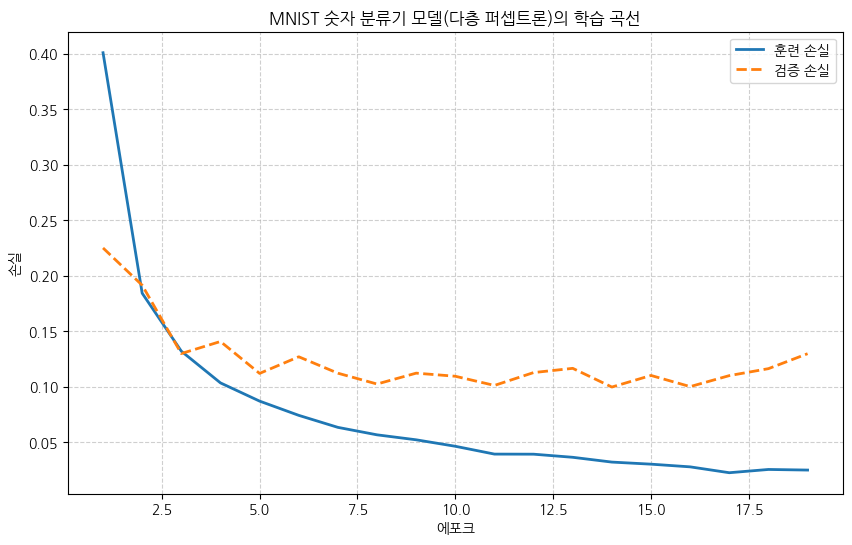

In [13]:
# 참고 - 숫자 분류기 모델의 학습 곡선
log.plot(title='MNIST 숫자 분류기 모델(다층 퍼셉트론)의 학습 곡선', y_label='손실')

## [코드 4-24] 훈련 데이터셋과 평가 데이터셋의 분류 정확도

평가 데이터로더로 분류 정확도를 계산한다. 본문은 텐서 직접 입력 형태의 `get_accuracy` 를 보여주므로 노트북에도 같은 형태를 둔다. `code_reference.common.get_accuracy()` (데이터로더 기반) 결과와도 비교한다.

In [14]:
########################################################################################
# 코드 4-22 - 훈련 데이터셋과 평가 데이터셋의 분류 정확도
########################################################################################

# 분류 정확도를 계산하는 함수
def get_accuracy(model, data_loader):
    model.eval()         
    correct_size = 0
    sample_size = 0           
    with torch.no_grad():
        # 데이터로더로부터 데이터를 받아서 분류 결과를 예측하고 정확도 계산
        for X, Y in data_loader:
            Y_pred = model(X)                                  # 로짓 예측
            classes = Y_pred.argmax(dim=1)                     # 분류 클래스 결정
            correct_size += (classes == Y).sum().item()        # 미니배치별 정답 수 누계
            sample_size += X.size(0)                           # 미니배치별 샘플 수 누계
    return correct_size / sample_size * 100   

accuracy_train = get_accuracy(model, train_loader)
accuracy_test = get_accuracy(model, test_loader)

print(f'훈련 데이터셋 분류 정확도: {accuracy_train:.2f}%')
print(f'평가 데이터셋 분류 정확도: {accuracy_test:.2f}%')

훈련 데이터셋 분류 정확도: 99.27%
평가 데이터셋 분류 정확도: 97.52%


## 참고 - 혼동 행렬 시각화 (본문 [코드 4-24] 이후 설명 대응)

본문은 정확도만으로 모델을 평가하기 어려울 때 혼동 행렬을 권한다. `common.get_confusion_matrix()` 로 10x10 혼동 행렬을 계산해 히트맵으로 그린다.

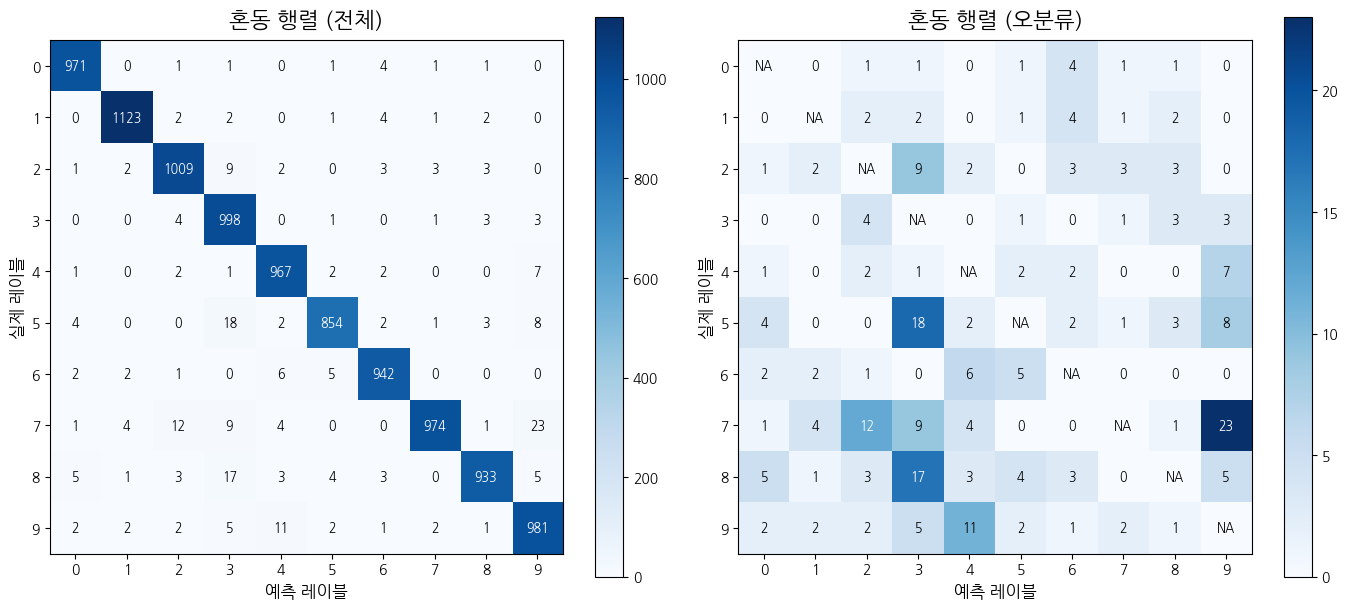

In [15]:
# 참고 - 혼동 행렬 계산 및 시각화([그림 5-1])

# 혼동 행렬 계산
cm = common.get_confusion_matrix(model, test_loader, num_classes=10)
# 혼동 행렬 시각화
viz.plot_confusion_matrix(cm, class_names=list('0123456789'))

## 정리

- torchvision 의 `datasets.MNIST` 로 내장 데이터셋을 손쉽게 불러온다.
- 이미지 변환은 `ToTensor`(0~1 정규화, (C, H, W) 변환), `Normalize`(표준화), `Resize`(크기 조정) 를 `transforms.Compose` 로 묶어 적용한다.
- 4-2 절의 미니배치 + 조기 종료 학습 함수를 그대로 재사용해 숫자 분류기를 학습·평가한다.

> 노트북 결과는 시드 42 기준이므로 본문 수치와 다를 수 있다. (출력 수치 반영은 2 단계 작업에서 다룬다.)

## 참고 - 5장 [그림 5-2] 대응: 주요 오답 패턴의 오분류 샘플 모음

본문 5-1 절 도입은 위 혼동 행렬에서 자주 틀리는 오답 패턴을 찾아, 해당 오분류 샘플을 직접 들여다본다. 비대각 원소 중 건수가 가장 많은 네 패턴에서 오분류 샘플을 앞에서부터 4 개씩 모아 4x4 격자로 표시한다. 각 행이 한 패턴에 해당하며, 제목의 `정답 → 예측` 표기로 어떤 오분류인지 표시한다.

7 → 9 오분류: 23건
5 → 3 오분류: 18건
8 → 3 오분류: 17건
7 → 2 오분류: 12건


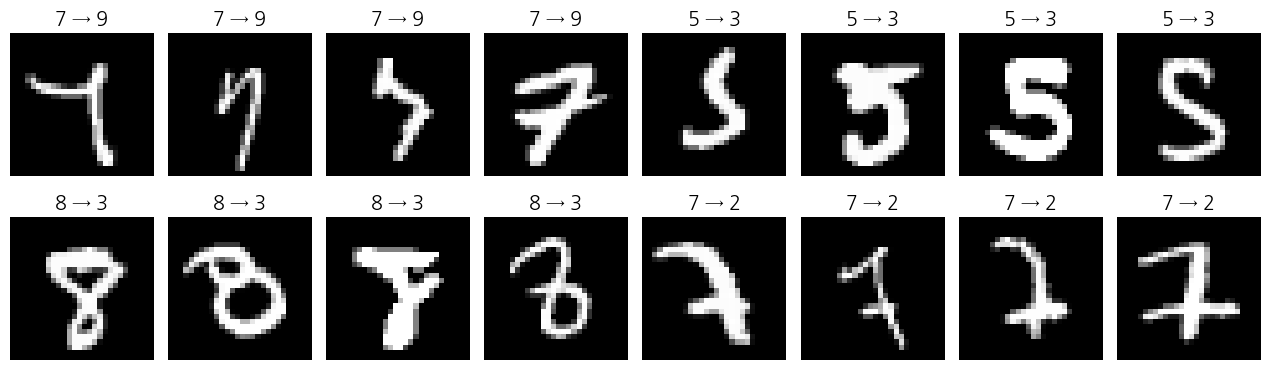

In [18]:
# 참고 - 주요 오답 패턴의 오분류 샘플 모음([그림 5-2])
# 평가 데이터셋 전체의 예측 레이블 수집
model.eval()
pred_list = []
with torch.no_grad():
    for inputs, _ in test_loader:
        outputs = model(inputs)
        pred_list.append(outputs.argmax(dim=1))
preds = torch.cat(pred_list)                # (10000,) 예측 레이블
labels = test_set.targets                   # (10000,) 정답 레이블

# 혼동 행렬(cm)의 비대각(오분류) 원소 중 건수가 가장 많은 네 가지 오답 패턴
error_cm = cm.clone()
error_cm.fill_diagonal_(0)                  # 정답(대각 원소)을 0으로 지워 오분류만 남김
top_values, top_indices = error_cm.flatten().topk(4)
patterns = [(int(i) // 10, int(i) % 10) for i in top_indices]
for (t, p), v in zip(patterns, top_values):
    print(f'{t} → {p} 오분류: {int(v)}건')

# 각 패턴의 오분류 샘플을 앞에서부터 4  개씩 수집
imgs, descs = [], []
for t, p in patterns:
    idxs = ((labels == t) & (preds == p)).nonzero().flatten()[:4]
    for idx in idxs:
        imgs.append(test_set.data[idx])     # 변환 전 원본 (28, 28) 이미지
        descs.append(f'{t} → {p}')
viz.plot_images(imgs, descs, images_per_row=8)

원본 예측: 0
원본 숫자 0의 로짓: 14.5784
원본 숫자 2의 로짓: -0.0812
이동본 예측: 2
이동본 숫자 0의 로짓: 1.8539
이동본 숫자 2의 로짓: 4.2811


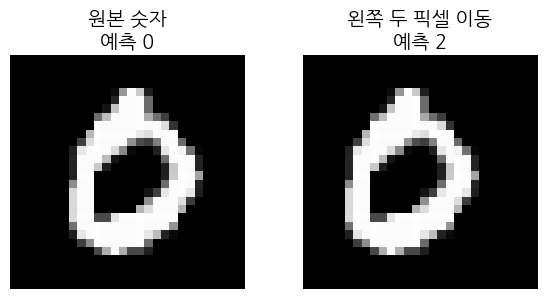

In [21]:
# 참고 - 평가 데이터셋에 포함된 0 이미지와 왼쪽으로 두 픽셀 이동한 0 이미지([그림 5-3])
# 평가 데이터셋의 첫 번째 0 샘플
for img, label in test_set:
    if label == 0:
        sample_0 = img
        break

# 왼쪽으로 두 픽셀 이동(오른쪽 두 열은 배경값 -1.0으로 채움)
sample_0_shifted = torch.full_like(sample_0, fill_value=-1.0)
sample_0_shifted[..., :-2] = sample_0[..., 2:]

# 원본과 이동본의 모델 예측 결과 비교
model.eval()
with torch.no_grad():    
    output_original = model(sample_0.unsqueeze(0))
    output_shifted = model(sample_0_shifted.unsqueeze(0))
    predicted_original = output_original.argmax(dim=1).item()
    predicted_shifted = output_shifted.argmax(dim=1).item()

print(f'원본 예측: {predicted_original}')                            
print(f'원본 숫자 0의 로짓: {output_original[0][0].item():.4f}')
print(f'원본 숫자 2의 로짓: {output_original[0][2].item():.4f}')
print(f'이동본 예측: {predicted_shifted}')                            
print(f'이동본 숫자 0의 로짓: {output_shifted[0][0].item():.4f}')
print(f'이동본 숫자 2의 로짓: {output_shifted[0][2].item():.4f}')

# 원본 vs 이동본 비교 시각화
viz.plot_images(
    [sample_0, sample_0_shifted],
    [f'원본 숫자\n예측 {predicted_original}', f'왼쪽 두 픽셀 이동\n예측 {predicted_shifted}'],
    images_per_row=2,
    figsize=(6, 3),
)